In [32]:
!git clone https://github.com/wwangwitsel/ConfDiff.git

Cloning into 'ConfDiff'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 33 (delta 11), reused 22 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 154.38 KiB | 25.73 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [33]:
%cd ConfDiff

/content/ConfDiff/ConfDiff


In [34]:
!pip install -q pandas scipy


In [ ]:
# Original Experiment
!python main.py -mo mlp -ds mnist -uci 0 -lr 1e-3 -wd 1e-5 -gpu 0 -ep 200 -seed 0 -bs 256 -pretrain_bs 256 -pretrain_ep 10 -me ConfDiffABS -prior 0.5 -n 15000 -run_times 1

the 0-th random round
#original train: torch.Size([60000, 1, 28, 28]) #original test torch.Size([10000, 1, 28, 28])
#all pretrain positive: torch.Size([29492, 1, 28, 28]) #all pretrain negative: torch.Size([30508, 1, 28, 28])
#all test positive: torch.Size([4926, 1, 28, 28]) #all test negative: torch.Size([5074, 1, 28, 28])
#epoch 0 : test_accuracy 0.4768
#epoch 1 : train_loss 0.048336129635572433  train_accuracy 0.9761333333333333  test_accuracy 0.9719
#epoch 2 : train_loss 0.008702983148396015  train_accuracy 0.9875666666666667  test_accuracy 0.9827
#epoch 3 : train_loss 0.08496979624032974  train_accuracy 0.9907166666666667  test_accuracy 0.9814
#epoch 4 : train_loss 0.15370164811611176  train_accuracy 0.9941833333333333  test_accuracy 0.9848
#epoch 5 : train_loss 0.07907320559024811  train_accuracy 0.9954666666666667  test_accuracy 0.9854
#epoch 6 : train_loss 0.0320889949798584  train_accuracy 0.99445  test_accuracy 0.9823
#epoch 7 : train_loss 0.041975680738687515  train_accuracy

Boiler plate

In [27]:
import subprocess, re
def confDiff(
    method="ConfDiffABS",
    n_pairs=15000,
    prior=0.5,
    run_times=2,
    dataset="mnist",
    model="mlp",
    uci=0,
    epochs=30,
    seed=0,
):
    # Run main.py once with given args and return (avg_acc, std_acc).
    cmd = [
        "python", "main.py",
        "-mo", model,
        "-ds", dataset,
        "-uci", str(uci),
        "-lr", "1e-3",
        "-wd", "1e-5",
        "-gpu", "0",
        "-ep", str(epochs),
        "-seed", str(seed),
        "-bs", "256",
        "-pretrain_bs", "256",
        "-pretrain_ep", "10",
        "-me", method,
        "-prior", str(prior),
        "-n", str(n_pairs),
        "-run_times", str(run_times),
    ]
    out = subprocess.check_output(cmd, text=True)
    avg, std = None, None
    for line in out.splitlines():
        if line.startswith("Avg_acc:"):
            # Expected format: Avg_acc:0.96447    std_acc:0.002
            m_avg = re.search(r"Avg_acc:([0-9.]+)", line)
            m_std = re.search(r"std_acc:([0-9.nNaA]+)", line)
            if m_avg:
                avg = float(m_avg.group(1))
            if m_std and m_std.group(1).lower() != "nan":
                std = float(m_std.group(1))
            break
    return avg, std, out

Hypothesis 1: Data efficiency trade-off

In [ ]:
import math
import pandas as pd
data = []
full = 15000      # 100% ConfDiff data for MNIST
fracs = [0.2, 0.4, 0.6, 0.8, 1.0]
h1_methods = ["ConfDiffUnbiased", "ConfDiffABS","ConfDiffReLU"]

for method in h1_methods:
    for frac in fracs:
        n_pairs = math.floor(full * frac)
        print(f"Hypothesis 1: method={method}, frac={frac}, n={n_pairs}")
        avg, std, _ = confDiff(
            method=method,
            n_pairs=n_pairs,
            prior=0.5,
            run_times=2,
            dataset="mnist",
            model="mlp",
            uci=0,
        )
        data.append({
            "hypothesis": "H1",
            "dataset": "mnist",
            "method": method,
            "frac": frac,
            "n_pairs": n_pairs,
            "prior": 0.5,
            "avg_acc": avg,
            "std_acc": std,
        })
df_h1 = pd.DataFrame(data)
df_h1


#ignore the plots in the cell output as they were automatically generated as I clicked a wrong button
#did not re-run or clear as it could have took a long time and outputs might differ

Hypothesis 1: method=ConfDiffUnbiased, frac=0.2, n=3000
Hypothesis 1: method=ConfDiffUnbiased, frac=0.4, n=6000
Hypothesis 1: method=ConfDiffUnbiased, frac=0.6, n=9000
Hypothesis 1: method=ConfDiffUnbiased, frac=0.8, n=12000
Hypothesis 1: method=ConfDiffUnbiased, frac=1.0, n=15000
Hypothesis 1: method=ConfDiffABS, frac=0.2, n=3000
Hypothesis 1: method=ConfDiffABS, frac=0.4, n=6000
Hypothesis 1: method=ConfDiffABS, frac=0.6, n=9000
Hypothesis 1: method=ConfDiffABS, frac=0.8, n=12000
Hypothesis 1: method=ConfDiffABS, frac=1.0, n=15000
Hypothesis 1: method=ConfDiffReLU, frac=0.2, n=3000
Hypothesis 1: method=ConfDiffReLU, frac=0.4, n=6000
Hypothesis 1: method=ConfDiffReLU, frac=0.6, n=9000
Hypothesis 1: method=ConfDiffReLU, frac=0.8, n=12000
Hypothesis 1: method=ConfDiffReLU, frac=1.0, n=15000


,hypothesis,dataset,method,frac,n_pairs,prior,avg_acc,std_acc
0,H1,mnist,ConfDiffUnbiased,0.2,3000,0.5,0.907750,0.001572
1,H1,mnist,ConfDiffUnbiased,0.4,6000,0.5,0.915200,0.008304
2,H1,mnist,ConfDiffUnbiased,0.6,9000,0.5,0.907207,0.031594
3,H1,mnist,ConfDiffUnbiased,0.8,12000,0.5,0.929801,0.001392
4,H1,mnist,ConfDiffUnbiased,1.0,15000,0.5,0.917946,0.035786
5,H1,mnist,ConfDiffABS,0.2,3000,0.5,0.916951,0.003072
6,H1,mnist,ConfDiffABS,0.4,6000,0.5,0.935952,0.003287
7,H1,mnist,ConfDiffABS,0.6,9000,0.5,0.948102,0.001335
8,H1,mnist,ConfDiffABS,0.8,12000,0.5,0.952532,0.000825
9,H1,mnist,ConfDiffABS,1.0,15000,0.5,0.953588,0.001170


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


from matplotlib import pyplot as plt
df_h1['frac'].plot(kind='hist', bins=20, title='frac')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df_h1['n_pairs'].plot(kind='hist', bins=20, title='n_pairs')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_18['method'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_18, x='frac', y='method', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_19['method'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_19, x='n_pairs', y='method', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_20['method'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_20, x='avg_acc', y='method', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

Plot for Hypothesis 1

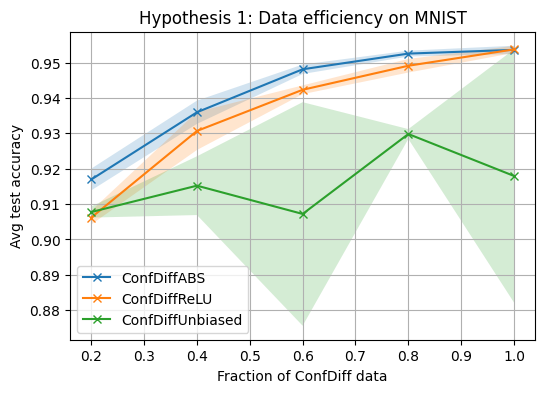

In [21]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(6,4))
for method, g in df_h1.groupby("method"):
    g = g.sort_values("frac")
    x = g["frac"].values
    y = g["avg_acc"].values
    yerr = g["std_acc"].fillna(0).values
    plt.plot(x, y, marker="x", label=method)
    plt.fill_between(x, y - yerr, y + yerr, alpha=0.2)
plt.grid(True)
plt.xlabel("Fraction of ConfDiff data")
plt.ylabel("Avg test accuracy")
plt.title("Hypothesis 1: Data efficiency on MNIST")
plt.legend()
plt.show()


Hypothesis 2: Robustness to hyperparameter uncertainty

In [29]:
priors = [0.3, 0.4, 0.5, 0.6, 0.7]
# testing only on ABS due to time constrains
# others will show the same pattern
h2_methods = ["ConfDiffABS"]
data = []
for method in h2_methods:
    for prior in priors:
        print(f"Hypothesis 2: method={method}, prior={prior}")
        avg,std, _ = confDiff(
            method=method,
            # n is fixed
            n_pairs=full,
            prior=prior,
            run_times=5,
            dataset="mnist",
            model="mlp",
            uci=0,
        )
        data.append({
            "hypothesis": "H2",
            "dataset": "mnist",
            "method": method,
            "frac": 1.0, # keeping fraction at 100%
            "n_pairs": full,
            "prior": prior,
            "avg_acc": avg,
            "std_acc": std,
        })
df_h2 = pd.DataFrame(data)
df_h2

Hypothesis 2: method=ConfDiffABS, prior=0.3
Hypothesis 2: method=ConfDiffABS, prior=0.4
Hypothesis 2: method=ConfDiffABS, prior=0.5
Hypothesis 2: method=ConfDiffABS, prior=0.6
Hypothesis 2: method=ConfDiffABS, prior=0.7


,hypothesis,dataset,method,frac,n_pairs,prior,avg_acc,std_acc
0,H2,mnist,ConfDiffABS,1.0,15000,0.3,0.956656,0.002606
1,H2,mnist,ConfDiffABS,1.0,15000,0.4,0.963070,0.001082
2,H2,mnist,ConfDiffABS,1.0,15000,0.5,0.963997,0.001432
3,H2,mnist,ConfDiffABS,1.0,15000,0.6,0.960818,0.000965
4,H2,mnist,ConfDiffABS,1.0,15000,0.7,0.951184,0.002483


Plot for Hypothesis 2

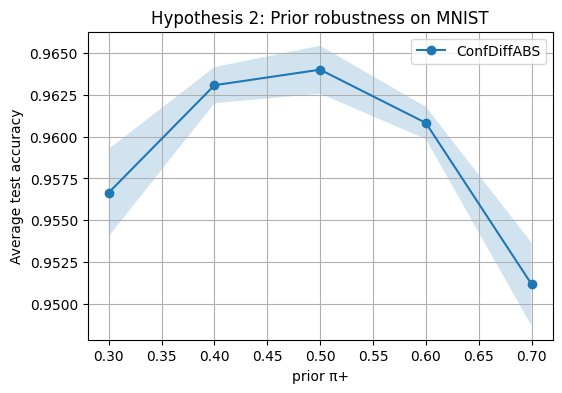

In [30]:
plt.figure(figsize=(6,4))
for method,g in df_h2.groupby("method"):
    g = g.sort_values("prior")
    x = g["prior"].values
    y = g["avg_acc"].values
    yerr = g["std_acc"].fillna(0).values
    plt.plot(x, y, marker="o", label=method)
    plt.fill_between(x, y - yerr, y + yerr, alpha=0.2)
plt.grid(True)
plt.xlabel("prior π+")
plt.ylabel("Average test accuracy")
plt.title("Hypothesis 2: Prior robustness on MNIST")
plt.legend()
plt.show()


Hypothesis 3: Variance control at low n

In [24]:
n = 3000
h3_methods = ["ConfDiffUnbiased","ConfDiffABS","ConfDiffReLU"]
data = []
for method in h3_methods:
    print(f"H3: method={method}, n_pairs={n}")
    avg, std, _ = confDiff(
        method=method,
        n_pairs=n,
        prior=0.5,
        run_times=10,   # more runs to estimate std
        dataset="mnist",
        model="mlp",
        uci=0,
    )
    data.append({
        "hypothesis": "H3",
        "dataset": "mnist",
        "method": method,
        "frac": n / full,
        "n_pairs": n,
        "prior": 0.5, #balanced
        "avg_acc": avg,
        "std_acc": std,
    })
df_h3 = pd.DataFrame(data)
df_h3

H3: method=ConfDiffUnbiased, n_pairs=3000
H3: method=ConfDiffABS, n_pairs=3000
H3: method=ConfDiffReLU, n_pairs=3000


,hypothesis,dataset,method,frac,n_pairs,prior,avg_acc,std_acc
0,H3,mnist,ConfDiffUnbiased,0.2,3000,0.5,0.908713,0.003456
1,H3,mnist,ConfDiffABS,0.2,3000,0.5,0.917477,0.003260
2,H3,mnist,ConfDiffReLU,0.2,3000,0.5,0.910467,0.004391


Plot for Hypothesis 3

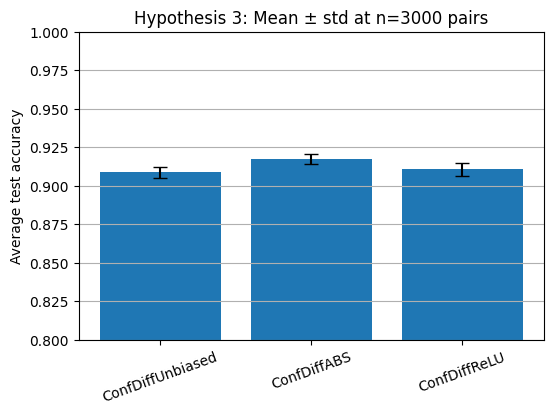

In [25]:
plt.figure(figsize=(6,4))
x = np.arange(len(df_h3))
means = df_h3["avg_acc"].values
stds = df_h3["std_acc"].fillna(0).values

plt.bar(x, means, yerr=stds, capsize=5)
plt.xticks(x, df_h3["method"].values, rotation=20)
plt.ylabel("Average test accuracy")
plt.title(f"Hypothesis 3: Mean ± std at n={n} pairs")
plt.ylim(0.8, 1.0)
plt.grid(axis="y")
plt.show()